In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

In [2]:
survey = pd.read_csv("with_features.csv")

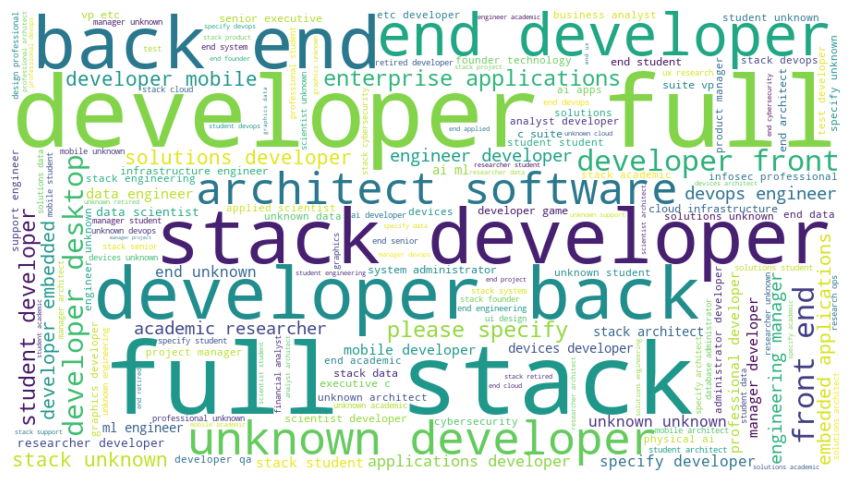

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    survey["PrimaryRole"]
    .dropna()
    .astype(str)
)

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# A quick way to visualize the most frequent words in job titles.

In [15]:
survey["PrimaryRole"] = survey["PrimaryRole"].replace({
    "developer, full-stack": "full-stack developer",
    "developer, back-end": "backend developer",
    "developer, front-end": "frontend developer",
    "data scientist": "data scientist",
    "engineering manager": "manager"
})

# Replace similar titles

In [16]:
from collections import Counter

words = " ".join(
    survey["PrimaryRole"]
).split()

Counter(words).most_common(20)

[('developer', 20236),
 ('full-stack', 11990),
 ('or', 9144),
 ('backend', 6291),
 ('unknown', 5469),
 ('developer,', 5299),
 ('engineer', 3359),
 ('student', 2992),
 ('applications', 2944),
 ('architect,', 2483),
 ('software', 2483),
 ('solutions', 2483),
 ('frontend', 1955),
 ('desktop', 1762),
 ('enterprise', 1762),
 ('other', 1695),
 ('(please', 1695),
 ('specify):', 1695),
 ('data', 1644),
 ('manager', 1500)]

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(
    survey["PrimaryRole"]
)

feature_names = vectorizer.get_feature_names_out()

scores = X.sum(axis=0).A1

tfidf = (
    pd.DataFrame({
        "Word": feature_names,
        "Score": scores
    })
    .sort_values("Score", ascending=False)
)

tfidf.head(20)

,Word,Score
16,developer,11691.037939
47,stack,9908.066787
8,backend,5545.054244
54,unknown,5469.000000
48,student,2992.000000
25,frontend,1823.653626
46,specify,1695.000000
20,engineer,1648.413242
4,applications,1480.543975
44,software,1433.560718


In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    survey["PrimaryRole"]
)

phrases = vectorizer.get_feature_names_out()

phrases[:30]